In [1]:
import sympy
from sympy import Eq, latex, plot_implicit, Matrix, simplify, expand, collect, symbols, acot
from sympy import pi as Pi
from sympy import cos as Cos
from sympy import sin as Sin
from IPython.display import Latex

# Практическое занятие 14
# Компьютерный практикум по алгебре на Python
### Задание 1.
Составить матрицу квадратичной формы $16x^2-21y^2+3z^2-4xy-4xz+10yz$, проверить, что она определяет именно заданный многочлен.

In [ ]:
from sympy.abc import x, y, z
A = Matrix([[16, -2, -2],
            [-2, -21, 5],
            [-2, 5, 3]])
u = 16 * x ** 2 - 21 * y ** 2 + 3 * z ** 2 - 4 * x * y - 4 * x * z + 10 * y * z
X = Matrix([x, y, z])
res = X.T * A * X
quadr_form = simplify(expand(res[0]))
display(Latex(f' X^T  A  X = {latex(quadr_form)},\ \
X^T  A  X - u = {latex(quadr_form - u)}'))

<IPython.core.display.Latex object>

### Задание 2.
Заданы векторы  $e_1=(1, 0, 1)$, $e_2=(-1, 0, 1)$, $e_1=(0, 1, 0)$.
Вывести (используя цикл!) на экран матрицу квадратичной формы Задания 1 в новом базисе из векторов


1.   ($e_1$, $e_2$, $e_3$),
2.   ($e_1$, $e_2 - e_1$, $e_3$),
3.   ($e_1$, $e_2$, $e_3 - e_1$),
4.   ($e_1$, $e_2 - e_1$, $e_3 - e_1$),
5.   ($e_1 + e_2$, $e_2$, $e_3 + e_2$),

при этом в файл "task2.xlsx" записать на листы $A_1$, $A_2$, ... матрицы в новом базисе, а на листы  $P_1$, $P_2$, ... соответствующие матрицы перехода.

In [ ]:
import pandas as pd
from google.colab import files

In [ ]:
e1 = Matrix([1, 0, 1])
e2 = Matrix([-1 ,0, 1])
e3 = Matrix([0, 1, 0])
res = [Matrix.hstack(e1, e2, e3),
       Matrix.hstack(e1, e2 - e1, e3),
       Matrix.hstack(e1, e2, e3 - e1),
       Matrix.hstack(e1, e2 - e1, e3 - e1),
       Matrix.hstack(e1 + e2, e2, e3 + e2)]

In [ ]:
with pd.ExcelWriter('task2.xlsx') as writer:
    for i, mx in enumerate(res):
        mx_inv = mx.T
        display(mx_inv * A * mx)
        result_matrix = pd.DataFrame((mx_inv*A*mx).tolist())
        result_matrix.to_excel(writer, sheet_name=f'A_{i + 1}', index=False, header=False)
        transformation_matrix = pd.DataFrame(mx.tolist())
        transformation_matrix.to_excel(writer, sheet_name=f'P_{i + 1}', index=False, header=False)
files.download('task2.xlsx')

Matrix([
[ 15, -13,   3],
[-13,  23,   7],
[  3,   7, -21]])

Matrix([
[ 15, -28,   3],
[-28,  64,   4],
[  3,   4, -21]])

Matrix([
[ 15, -13, -12],
[-13,  23,  20],
[-12,  20, -12]])

Matrix([
[ 15, -28, -12],
[-28,  64,  32],
[-12,  32, -12]])

Matrix([
[12, 10, 20],
[10, 23, 30],
[20, 30, 16]])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Задание 3.
В цикле из файла "sem_14_task_3.xlsx" считать матрицы, вывести на экран каждую матрицу и ее собственные числа и собственные векторы.

In [ ]:
uploaded = files.upload()
for file_name in uploaded.keys():
    display(Latex(f'Загружен\ файл\ {latex(file_name)}'))
    xls = pd.ExcelFile(file_name)
    sheet_names = xls.sheet_names
    for sheet_name in sheet_names:
        display(Latex(f'Матрица\ на\ листе\ {sheet_name}:'))
        df = pd.read_excel(file_name, sheet_name=sheet_name, index_col=False, header=None)
        matrix = df.to_numpy()
        M = Matrix(matrix)
        display(M)
        eigenvects = M.eigenvects()
        for eigenvalue, multiplicity, eigenvectors in eigenvects:
            display(Latex(f'Собственное\ число:'))
            display(eigenvalue)
            display(Latex(f'Собственные\ векторы:'))
            display(*eigenvectors)

Saving sem_14_task_3.xlsx to sem_14_task_3.xlsx


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Matrix([
[  7, 37, -37],
[ 37, -5,   5],
[-37,  5,  -5]])

<IPython.core.display.Latex object>

...

Matrix([
[81/64 - sqrt(10657)/64],
[                     1],
[                     0]])

<IPython.core.display.Latex object>

71/2 + sqrt(10657)/2

<IPython.core.display.Latex object>

Matrix([
[81/64 + sqrt(10657)/64],
[                     1],
[                     0]])

### Задание 4.
Привести квадратичную форму с матрицей
$$
\left[\begin{matrix}-645 & -12 & -960\\-12 & 3 & 9\\-960 & 9 & -1205\end{matrix}\right]
$$
к каноническому виду с помощью перехода к новому базису из собственных векторов.

Вывести на экран матрицу перехода к новому базису, матрицу квадратичной формы в новом базисе и квадратичную форму в старом и новом базисе (в виде многочлена от переменных $x$, $y$, $z$).

In [ ]:
A = Matrix([[-645, -12, -960],
            [-12, 3, 9],
            [-960, 9, -1205]])

ev = A.eigenvects()
P = ev[0][2][0].row_join(ev[1][2][0]).row_join(ev[2][2][0])
display(P)

Matrix([
[3/4,  -4/3, -4/3],
[  0, -25/3,  1/3],
[  1,     1,    1]])

In [ ]:
x, y, z = symbols('x y z')
X = Matrix([x, y, z])
A_new = simplify(P.inv() * A * P)
display(A_new)

Matrix([
[-1925, 0,  0],
[    0, 0,  0],
[    0, 0, 78]])

In [ ]:
old_quad_form = X.T * A * X
new_quad_form = X.T * A_new * X

display(*simplify(old_quad_form))
display(*new_quad_form)

-645*x**2 - 24*x*y - 1920*x*z + 3*y**2 + 18*y*z - 1205*z**2

-1925*x**2 + 78*z**2

### Задание 5*.
Определить тип кривой второго порядка, заданной уравнением
$$
97x^2 - 144xy + 97y^2 + 482x - 532y = 3452
$$
Построить в одной координатной плоскости график заданного уравнения и канонического уравнения соответствующей кривой, каноническое уравнение сделать названием графика.

In [ ]:
from sympy.abc import X, Y, Z

In [ ]:
A = Matrix([[97, -72, 241],
            [-72, 97, -266],
            [241, -266, -3452]])
X = Matrix([x, y, 1])
discriminant = A[1, 1] ** 2 - 4 * A[0, 0] * A[2, 2]

In [ ]:
if discriminant > 0:
    curve_type = 'Эллипс'
elif discriminant < 0:
    curve_type = 'Гипербола'
else:
    curve_type = 'Парабола'

In [ ]:
eq = Eq(simplify(expand(X.T * A * X))[0], 0)
alpha = acot((A[0, 0] - A[1, 1]) / (2 * A[0, 1])) / 2
P = Matrix([[Cos(alpha), -Sin(alpha), 0],
            [Sin(alpha), Cos(alpha), 0],
            [0, 0, 1]])
P.simplify()
display(P)

Matrix([
[sqrt(2)/2, -sqrt(2)/2, 0],
[sqrt(2)/2,  sqrt(2)/2, 0],
[        0,          0, 1]])

In [ ]:
A_new = P.T * A * P
A_new.simplify()

X_new = Matrix((X - A_new[0, 2] / A_new[0, 0],
                 Y - A_new[1, 2] / A_new[1, 1],
                 1))
eq_new = simplify(expand((X_new.T * A_new * X_new))[0])

free = eq_new.subs({X: 0, Y: 0})
eq_last = eq_new / (-free) + 1
eq_last_xy = Eq(eq_last.subs({X: x, Y: y}), 1)
display(eq_last_xy)

Eq(x**2/169 + y**2/25, 1)

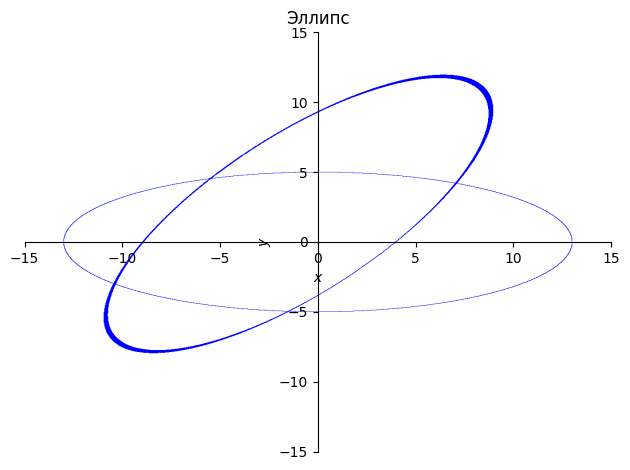

In [ ]:
p = plot_implicit(eq, (x, -15, 15), (y, -15, 15),show = False)
p.extend(plot_implicit(eq_last_xy, (x, -15, 15), (y, -15, 15),show=False))
p.title = f'{curve_type}'
p.show()

### Задание 6*.
Определить тип кривой второго порядка, заданной уравнением
$$
x^2+2xy+y^2-4x+4y=4
$$
Построить в одной координатной плоскости график заданного уравнения и канонического уравнения соответствующей кривой, каноническое уравнение сделать названием графика.

Указание: каноническое уравнение параболы $y^2 = 2px$ или $x^2 = 2py$; для того, чтобы выразить $x$ или $y$ можно воспользоваться solve или solveset.

###  Индивидуальное задание. Вариант №191
Составить матрицу квадратичной формы и привести ее к каноническому виду с помощью перехода к новому базису из собственных векторов. Векторы выводить на экран не нужно. Вывести на экран матрицу в исходном виде и канонической форме, а также саму квадратичную форму в каноническом виде.

In [ ]:
from sympy import sqrt

In [ ]:
Q = Matrix([[6946, -285 * sqrt(21), 393 * sqrt(91)],
            [-285 * sqrt(21), 3100, 665 * sqrt(39)],
            [393 * sqrt(91), 665 * sqrt(39), -3796]])
Q

Matrix([
[         6946, -285*sqrt(21), 393*sqrt(91)],
[-285*sqrt(21),          3100, 665*sqrt(39)],
[ 393*sqrt(91),  665*sqrt(39),        -3796]])

In [ ]:
ev = Q.eigenvects()
P = ev[0][2][0].row_join(ev[1][2][0]).row_join(ev[2][2][0])
D = simplify(P.inv() * Q * P)
D

Matrix([
[-6875,    0,    0],
[    0, 5000,    0],
[    0,    0, 8125]])

In [ ]:
D[0, 0] * x**2 + D[1, 1] * y**2 + D[2, 2] * z**2

-6875*x**2 + 5000*y**2 + 8125*z**2